In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

# Saudi Aramco Discounted Cash Flow (DCF) Valuation Model
This notebook calculates the intrinsic value of Saudi Aramco based on Free Cash Flow (FCF) projections.

In [20]:
# Fetch Aramco stock data
ticker = "2222.SR"
aramco = yf.Ticker(ticker)
 
# Get current stock price
current_price = aramco.history(period="1d")['Close'].iloc[-1]
print(f"Current Aramco Stock Price: {current_price:.2f} SAR")
print(f"Date: {datetime.now().strftime('%Y-%m-%d')}")
print("\n" + "="*70 + "\n")


Current Aramco Stock Price: 27.92 SAR
Date: 2026-05-13




In [21]:
print("ASSUMPTIONS")
print("="*70)
 
# Financial assumptions (based on latest Aramco financials)
latest_revenue_billions_sar = 550  # 2023/2024 revenue in billions SAR (adjust based on latest report)
latest_fcf_conversion = 0.22  # Free cash flow as % of revenue (historical: ~20-25%)
tax_rate = 0.15  # Saudi corporate tax rate
wacc = 0.08  # Weighted average cost of capital (8-9% typical for large cap)
terminal_growth = 0.025  # Long-term perpetual growth (2-3%)
 
# Revenue growth projections
revenue_growth_rates = [0.05, 0.04, 0.03, 0.03, 0.02]  # Years 1-5: declining growth
 
# Margin assumptions
ebitda_margin = 0.40  # EBITDA as % of revenue (Aramco: ~38-42%)
 
print(f"Latest Revenue (SAR billions): {latest_revenue_billions_sar}")
print(f"EBITDA Margin: {ebitda_margin*100:.1f}%")
print(f"Tax Rate: {tax_rate*100:.1f}%")
print(f"WACC (Discount Rate): {wacc*100:.1f}%")
print(f"Terminal Growth Rate: {terminal_growth*100:.1f}%")
print(f"FCF Conversion to Revenue: {latest_fcf_conversion*100:.1f}%")
print(f"\nRevenue Growth Rates (Year 1-5): {[f'{x*100:.1f}%' for x in revenue_growth_rates]}")
print("\n" + "="*70 + "\n")

ASSUMPTIONS
Latest Revenue (SAR billions): 550
EBITDA Margin: 40.0%
Tax Rate: 15.0%
WACC (Discount Rate): 8.0%
Terminal Growth Rate: 2.5%
FCF Conversion to Revenue: 22.0%

Revenue Growth Rates (Year 1-5): ['5.0%', '4.0%', '3.0%', '3.0%', '2.0%']




In [22]:
print("5-YEAR REVENUE & EBITDA PROJECTIONS")
print("="*70)
 
years = np.arange(1, 6)
revenues = []
ebitdas = []
 
# Base year
revenue = latest_revenue_billions_sar
 
for i, growth_rate in enumerate(revenue_growth_rates):
    revenue = revenue * (1 + growth_rate)
    ebitda = revenue * ebitda_margin
    revenues.append(revenue)
    ebitdas.append(ebitda)
    print(f"Year {i+1}: Revenue = {revenue:.1f}B SAR | EBITDA = {ebitda:.1f}B SAR | Growth = {growth_rate*100:.1f}%")
 
revenues = np.array(revenues)
ebitdas = np.array(ebitdas)
print("\n" + "="*70 + "\n")

5-YEAR REVENUE & EBITDA PROJECTIONS
Year 1: Revenue = 577.5B SAR | EBITDA = 231.0B SAR | Growth = 5.0%
Year 2: Revenue = 600.6B SAR | EBITDA = 240.2B SAR | Growth = 4.0%
Year 3: Revenue = 618.6B SAR | EBITDA = 247.4B SAR | Growth = 3.0%
Year 4: Revenue = 637.2B SAR | EBITDA = 254.9B SAR | Growth = 3.0%
Year 5: Revenue = 649.9B SAR | EBITDA = 260.0B SAR | Growth = 2.0%




In [23]:
print("FREE CASH FLOW PROJECTIONS (5-Year)")
print("="*70)
 
# Simplified FCF = EBITDA × (1 - Tax Rate) × FCF Conversion Rate
# In reality: FCF = NOPAT - CapEx - Changes in Working Capital
# But this approximation works for a quick valuation
 
fcfs = ebitdas * (1 - tax_rate) * latest_fcf_conversion
 
for i, fcf in enumerate(fcfs):
    print(f"Year {i+1} FCF: {fcf:.2f}B SAR")
 
print("\n" + "="*70 + "\n")

FREE CASH FLOW PROJECTIONS (5-Year)
Year 1 FCF: 43.20B SAR
Year 2 FCF: 44.92B SAR
Year 3 FCF: 46.27B SAR
Year 4 FCF: 47.66B SAR
Year 5 FCF: 48.61B SAR




In [24]:
print("DISCOUNTED CASH FLOWS")
print("="*70)
 
discount_factors = (1 + wacc) ** years
pv_fcfs = fcfs / discount_factors
 
total_pv_fcfs = pv_fcfs.sum()
 
for i, (fcf, df, pv) in enumerate(zip(fcfs, discount_factors, pv_fcfs)):
    print(f"Year {i+1}: FCF = {fcf:.2f}B SAR | Discount Factor = {df:.4f} | PV = {pv:.2f}B SAR")
 
print(f"\nTotal PV of 5-Year FCFs: {total_pv_fcfs:.2f}B SAR")
print("\n" + "="*70 + "\n")

DISCOUNTED CASH FLOWS
Year 1: FCF = 43.20B SAR | Discount Factor = 1.0800 | PV = 40.00B SAR
Year 2: FCF = 44.92B SAR | Discount Factor = 1.1664 | PV = 38.52B SAR
Year 3: FCF = 46.27B SAR | Discount Factor = 1.2597 | PV = 36.73B SAR
Year 4: FCF = 47.66B SAR | Discount Factor = 1.3605 | PV = 35.03B SAR
Year 5: FCF = 48.61B SAR | Discount Factor = 1.4693 | PV = 33.09B SAR

Total PV of 5-Year FCFs: 183.36B SAR




In [25]:
print("TERMINAL VALUE & VALUATION")
print("="*70)
 
# Terminal value = Year 5 FCF × (1 + g) / (WACC - g)
terminal_fcf = fcfs[-1] * (1 + terminal_growth)
terminal_value = terminal_fcf / (wacc - terminal_growth)
discount_factor_terminal = (1 + wacc) ** 5
pv_terminal_value = terminal_value / discount_factor_terminal
 
print(f"Year 5 FCF: {fcfs[-1]:.2f}B SAR")
print(f"Terminal Growth Rate: {terminal_growth*100:.1f}%")
print(f"Terminal Value (Year 5): {terminal_value:.2f}B SAR")
print(f"Discount Factor (Year 5): {discount_factor_terminal:.4f}")
print(f"PV of Terminal Value: {pv_terminal_value:.2f}B SAR")
print("\n" + "-"*70 + "\n")
 
# Enterprise Value
enterprise_value = total_pv_fcfs + pv_terminal_value
print(f"Enterprise Value: {enterprise_value:.2f}B SAR")
 
# For Aramco, we need to adjust for net debt
# Simplified: assume net cash (Aramco typically has cash > debt)
net_debt_billions = -50  # Negative = net cash position (adjust based on latest balance sheet)
equity_value = enterprise_value - net_debt_billions
 
print(f"Net Debt: {net_debt_billions:.2f}B SAR (negative = net cash)")
print(f"Equity Value: {equity_value:.2f}B SAR")
 
# Shares outstanding (Aramco has ~2.4B shares)
shares_outstanding_billions = 2.4
intrinsic_price = equity_value / shares_outstanding_billions  # Both in billions, result is SAR per share
 
print(f"\nShares Outstanding: {shares_outstanding_billions:.2f}B")
print(f"Intrinsic Price per Share: {intrinsic_price:.2f} SAR")
print(f"Current Market Price: {current_price:.2f} SAR")
upside = ((intrinsic_price - current_price) / current_price) * 100
print(f"Upside/(Downside): {upside:+.1f}%")
print("\n" + "="*70 + "\n")
 

TERMINAL VALUE & VALUATION
Year 5 FCF: 48.61B SAR
Terminal Growth Rate: 2.5%
Terminal Value (Year 5): 905.99B SAR
Discount Factor (Year 5): 1.4693
PV of Terminal Value: 616.60B SAR

----------------------------------------------------------------------

Enterprise Value: 799.96B SAR
Net Debt: -50.00B SAR (negative = net cash)
Equity Value: 849.96B SAR

Shares Outstanding: 2.40B
Intrinsic Price per Share: 354.15 SAR
Current Market Price: 27.92 SAR
Upside/(Downside): +1168.5%




In [26]:
print("SENSITIVITY ANALYSIS")
print("="*70)
print("\nIntrinsic Price Sensitivity to WACC and Terminal Growth\n")
 
# Range of assumptions
wacc_range = np.arange(0.06, 0.12, 0.01)  # 6% to 11%
growth_range = np.arange(0.01, 0.05, 0.005)  # 1% to 4.5%
 
# Create sensitivity table
sensitivity_table = np.zeros((len(wacc_range), len(growth_range)))
 
for i, wacc_sens in enumerate(wacc_range):
    for j, growth_sens in enumerate(growth_range):
        # Recalculate with different assumptions
        discount_factors_sens = (1 + wacc_sens) ** years
        pv_fcfs_sens = fcfs / discount_factors_sens
        total_pv_sens = pv_fcfs_sens.sum()
        
        terminal_fcf_sens = fcfs[-1] * (1 + growth_sens)
        terminal_value_sens = terminal_fcf_sens / (wacc_sens - growth_sens)
        pv_terminal_sens = terminal_value_sens / ((1 + wacc_sens) ** 5)
        
        enterprise_value_sens = total_pv_sens + pv_terminal_sens
        equity_value_sens = enterprise_value_sens - net_debt_billions
        intrinsic_price_sens = equity_value_sens / shares_outstanding_billions
        
        sensitivity_table[i, j] = intrinsic_price_sens
 
# Create DataFrame for better display
sensitivity_df = pd.DataFrame(
    sensitivity_table,
    index=[f"{x*100:.0f}%" for x in wacc_range],
    columns=[f"{x*100:.1f}%" for x in growth_range]
)
 
print(sensitivity_df.round(2))
print("\n(Values in SAR per share)")
print("\n" + "="*70 + "\n")

SENSITIVITY ANALYSIS

Intrinsic Price Sensitivity to WACC and Terminal Growth

       1.0%    1.5%    2.0%    2.5%    3.0%    3.5%    4.0%     4.5%
6%   407.28  442.94  487.50  544.81  621.21  728.17  888.62  1156.03
7%   342.44  365.86  393.95  428.29  471.22  526.41  600.00   703.02
8%   296.14  312.51  331.59  354.15  381.22  414.31  455.67   508.84
9%   261.43  273.39  287.05  302.82  321.22  342.96  369.05   400.94
10%  234.44  243.48  253.65  265.18  278.36  293.56  311.30   332.26
11%  212.85  219.87  227.68  236.40  246.21  257.33  270.04   284.70

(Values in SAR per share)




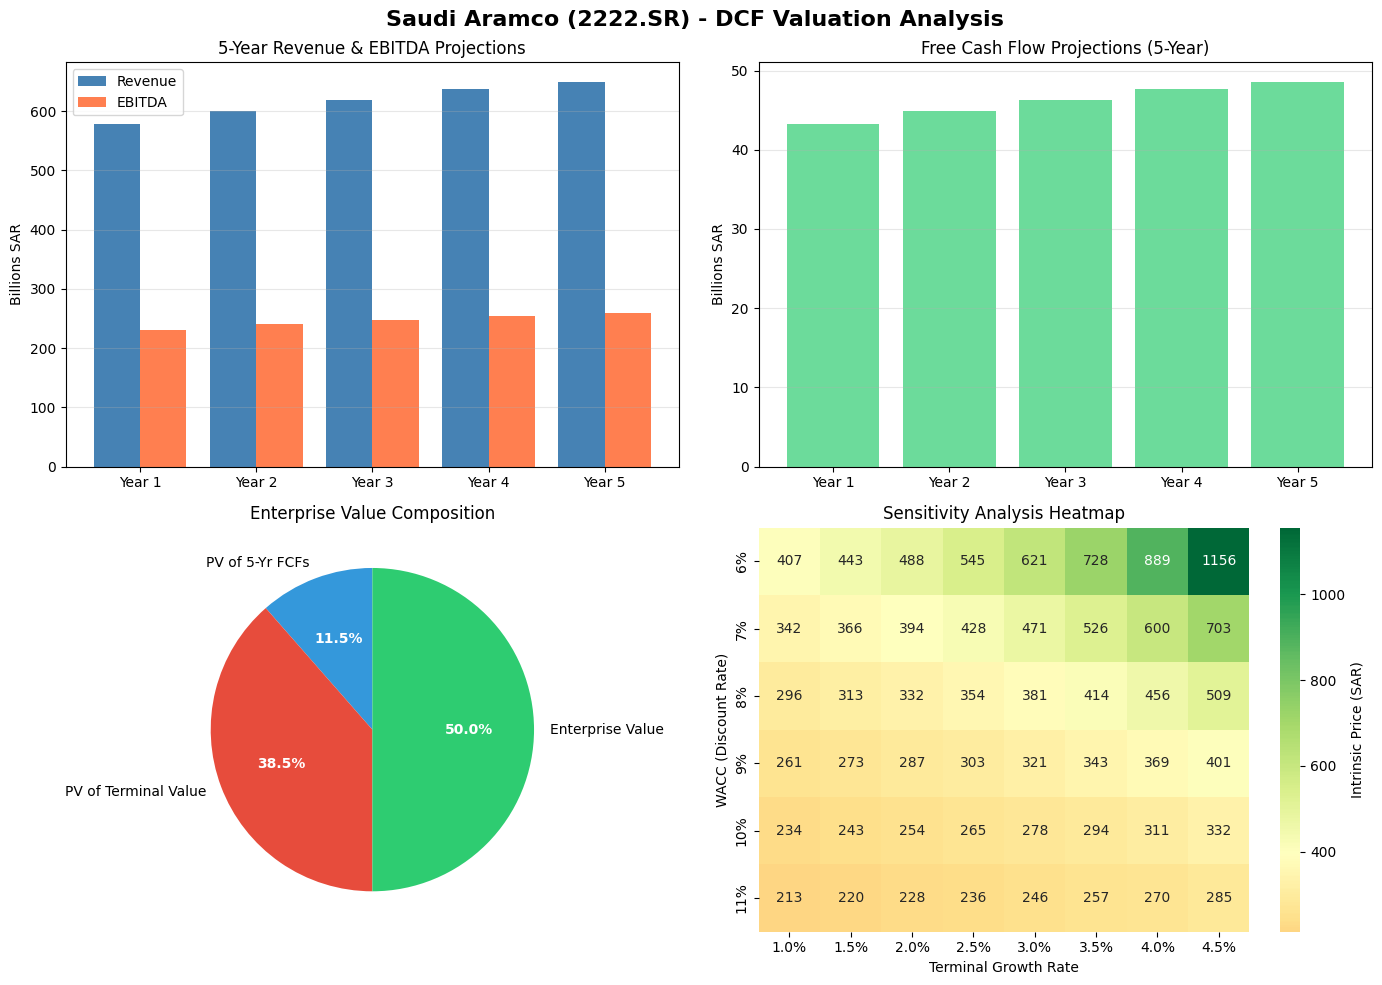

In [27]:
# Setup plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Saudi Aramco (2222.SR) - DCF Valuation Analysis', fontsize=16, fontweight='bold')
 
# Plot 1: Revenue & EBITDA Projections
ax1 = axes[0, 0]
years_labels = [f'Year {i}' for i in range(1, 6)]
ax1.bar(np.arange(len(years_labels)) - 0.2, revenues, 0.4, label='Revenue', color='steelblue')
ax1.bar(np.arange(len(years_labels)) + 0.2, ebitdas, 0.4, label='EBITDA', color='coral')
ax1.set_ylabel('Billions SAR')
ax1.set_title('5-Year Revenue & EBITDA Projections')
ax1.set_xticks(np.arange(len(years_labels)))
ax1.set_xticklabels(years_labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
 
# Plot 2: FCF Waterfall
ax2 = axes[0, 1]
fcf_labels = [f'Year {i}' for i in range(1, 6)]
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in fcfs]
ax2.bar(fcf_labels, fcfs, color=colors, alpha=0.7)
ax2.set_ylabel('Billions SAR')
ax2.set_title('Free Cash Flow Projections (5-Year)')
ax2.grid(axis='y', alpha=0.3)
 
# Plot 3: PV Contribution
ax3 = axes[1, 0]
components = ['PV of 5-Yr FCFs', 'PV of Terminal Value', 'Enterprise Value']
values = [total_pv_fcfs, pv_terminal_value, enterprise_value]
colors_pie = ['#3498db', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax3.pie(values, labels=components, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax3.set_title('Enterprise Value Composition')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
 
# Plot 4: Sensitivity Heatmap
ax4 = axes[1, 1]
sns.heatmap(sensitivity_table, annot=True, fmt='.0f', cmap='RdYlGn', center=float(sensitivity_table.mean()),
            xticklabels=[f'{x*100:.1f}%' for x in growth_range],
            yticklabels=[f'{x*100:.0f}%' for x in wacc_range],
            ax=ax4, cbar_kws={'label': 'Intrinsic Price (SAR)'})
ax4.set_xlabel('Terminal Growth Rate')
ax4.set_ylabel('WACC (Discount Rate)')
ax4.set_title('Sensitivity Analysis Heatmap')
 
plt.tight_layout()